# Exercícios de KNN — Resolução

Resolução dos exercícios do **Guia de Estudos - Prova.md**, seguindo o mesmo padrão de código
usado na Aula 7 (KNN implementado apenas com Numpy e Matplotlib).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


### Funções do algoritmo KNN

In [2]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2) ** 2))


def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos


def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao


## Exercício 1 — Classificação com K=3 e K=5

Dataset (tamanho do tumor, textura → classe: 0=benigno, 1=maligno):

| Ponto | tamanho | textura | classe |
|---|---|---|---|
| P1 | 2 | 3 | 0 |
| P2 | 3 | 2 | 0 |
| P3 | 8 | 8 | 1 |
| P4 | 7 | 9 | 1 |
| P5 | 1 | 1 | 0 |
| P6 | 9 | 7 | 1 |

**Perguntas:** classifique o novo ponto (4, 4) com K=3 e com K=5. A classificação muda?

#### Obtendo X_train e y_train — duas formas equivalentes

In [3]:
# Forma 1: dados digitados direto no código
X_train = np.array([[2, 3], [3, 2], [8, 8], [7, 9], [1, 1], [9, 7]])
y_train = np.array([0, 0, 1, 1, 0, 1])

print("X_train:\n", X_train)
print("y_train:", y_train)


X_train:
 [[2 3]
 [3 2]
 [8 8]
 [7 9]
 [1 1]
 [9 7]]
y_train: [0 0 1 1 0 1]


In [4]:
# Forma 2: carregando os MESMOS dados de um arquivo CSV
# arquivo "exercicio1_tumores.csv":
#   tamanho,textura,classe
#   2,3,0
#   3,2,0
#   ...
dados = np.loadtxt("exercicio1_tumores.csv", delimiter=",", skiprows=1)
X_train = dados[:, :2].astype(int)   # colunas 0 e 1 do arquivo = tamanho, textura
y_train = dados[:, 2].astype(int)    # última coluna do arquivo = classe (y)

print("X_train:\n", X_train)
print("y_train:", y_train)


X_train:
 [[2 3]
 [3 2]
 [8 8]
 [7 9]
 [1 1]
 [9 7]]
y_train: [0 0 1 1 0 1]


In [5]:
# Ponto que queremos classificar
novo_ponto = np.array([4, 4])

# Calculando a distância até cada ponto de treino
for i, ponto in enumerate(X_train):
    dist = calcular_distancia_euclidiana(ponto, novo_ponto)
    print(f"Distância até P{i + 1} {tuple(ponto.tolist())} (classe {y_train[i]}): {dist:.3f}")


Distância até P1 (2, 3) (classe 0): 2.236
Distância até P2 (3, 2) (classe 0): 2.236
Distância até P3 (8, 8) (classe 1): 5.657
Distância até P4 (7, 9) (classe 1): 5.831
Distância até P5 (1, 1) (classe 0): 4.243
Distância até P6 (9, 7) (classe 1): 5.831


In [6]:
# Classificando com K=3 e K=5
for k in [3, 5]:
    vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
    previsao_final = prever_classificacao(vizinhos_proximos)
    resultado_texto = "Benigno" if previsao_final == 0 else "Maligno"

    print(f"K={k}")
    print(f"  Vizinhos mais próximos (classes): {[int(v) for v in vizinhos_proximos]}")
    print(f"  --> Previsão: {resultado_texto} (Classe {previsao_final})\n")


K=3
  Vizinhos mais próximos (classes): [0, 0, 0]
  --> Previsão: Benigno (Classe 0)

K=5
  Vizinhos mais próximos (classes): [0, 0, 0, 1, 1]
  --> Previsão: Benigno (Classe 0)



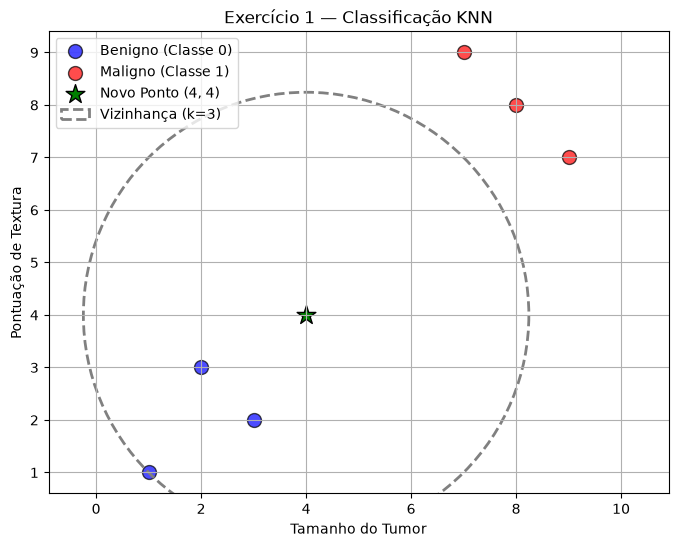

In [7]:
# Visualizando o resultado com K=3
k = 3
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (Classe 0)')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Maligno (Classe 1)')
ax.scatter(novo_ponto[0], novo_ponto[1], c='green', s=200, edgecolor='k',
           marker='*', label='Novo Ponto (4, 4)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort(
    [calcular_distancia_euclidiana(p, novo_ponto) for p in X_train]
)[:k]
pontos_vizinhos = X_train[indices_vizinhos]
distancia_maxima = calcular_distancia_euclidiana(novo_ponto, pontos_vizinhos[-1])
circulo = plt.Circle(novo_ponto, distancia_maxima, color='gray', fill=False,
                      linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Exercício 1 — Classificação KNN')
ax.set_xlabel('Tamanho do Tumor')
ax.set_ylabel('Pontuação de Textura')
ax.legend(loc='upper left')
ax.grid(True)
ax.set_aspect('equal', adjustable='datalim')
plt.show()


### Respostas — Exercício 1

**a)** Distâncias calculadas na célula acima (P1 e P2 ≈ 2,236, os mais próximos; P5 ≈ 4,243;
P3, P4 e P6 ≈ 5,657–5,831, os mais distantes).

**b)** Os 3 mais próximos com K=3 são **P1, P2 e P5** (classes 0, 0, 0) → **classificado como
benigno (0)**, votação unânime.

**c)** Com K=5 entram também P3 e P4 (classe 1 cada) → votos: 3 para classe 0, 2 para classe 1 →
**continua benigno (0)**, a classificação não muda (mas a margem fica mais apertada).

**d)** Porque o cálculo de distância trata todas as variáveis igualmente em valor numérico — se
uma variável tiver uma escala muito maior que a outra (ex.: uma em milhares e outra entre 0 e 1),
ela dominaria a distância mesmo sem ser mais importante. Normalizar coloca todas as variáveis na
mesma escala antes de medir a distância.

## Exercício 2 — KNN regressão

Preveja o preço de um imóvel de 72 m² usando KNN regressão (K=3):

| Área | 50 | 55 | 60 | 85 | 90 |
|---|---|---|---|---|---|
| Preço | 200 | 210 | 220 | 380 | 400 |

**Perguntas:** a) calcule as distâncias; b) quais os 3 vizinhos mais próximos; c) preço previsto?

#### Obtendo área e preço — duas formas equivalentes

In [8]:
# Forma 1: dados digitados direto no código
areas = np.array([50, 55, 60, 85, 90])
precos = np.array([200, 210, 220, 380, 400])

print("areas:", areas)
print("precos:", precos)


areas: [50 55 60 85 90]
precos: [200 210 220 380 400]


In [9]:
# Forma 2: carregando os MESMOS dados de um arquivo CSV
# arquivo "exercicio2_imoveis.csv":
#   area,preco
#   50,200
#   55,210
#   ...
dados = np.loadtxt("exercicio2_imoveis.csv", delimiter=",", skiprows=1)
areas = dados[:, 0].astype(int)   # 1ª coluna do arquivo = área
precos = dados[:, 1].astype(int)  # 2ª coluna do arquivo = preço

print("areas:", areas)
print("precos:", precos)


areas: [50 55 60 85 90]
precos: [200 210 220 380 400]


In [10]:
novo_imovel = 72
k = 3

# Calculando e ordenando as distâncias (1D: valor absoluto da diferença)
distancias = sorted(zip(np.abs(areas - novo_imovel), precos), key=lambda t: t[0])

for dist, preco in distancias:
    print(f"Distância: {dist} | Preço: {preco}")


Distância: 12 | Preço: 220
Distância: 13 | Preço: 380
Distância: 17 | Preço: 210
Distância: 18 | Preço: 400
Distância: 22 | Preço: 200


In [11]:
# Previsão pela MÉDIA dos k vizinhos mais próximos (KNN regressão)
vizinhos_proximos = [int(preco) for _, preco in distancias[:k]]
preco_previsto = np.mean(vizinhos_proximos)

print(f"K={k} vizinhos mais próximos (preços): {vizinhos_proximos}")
print(f"Preço previsto para imóvel de {novo_imovel} m²: R$ {preco_previsto:.2f}")


K=3 vizinhos mais próximos (preços): [220, 380, 210]
Preço previsto para imóvel de 72 m²: R$ 270.00


### Respostas — Exercício 2

**a)** Distâncias calculadas na célula acima: 12, 13, 17, 18, 22 (para áreas 60, 85, 55, 90, 50).

**b)** Os 3 vizinhos mais próximos (K=3) são os imóveis de área 60 (preço 220), 85 (preço 380) e
55 (preço 210).

**c)** Preço previsto = **R\$ 270,00** (média dos 3 vizinhos, calculado na célula acima).

**d)** Resposta aberta, mas a esperada: como a relação entre área e preço parece ser bem linear e
crescente (padrão visível nos dados), a **Regressão Linear Simples** tende a generalizar melhor e
é mais simples de interpretar (dá um coeficiente único de "R$ por m²"); o KNN, aqui, é mais
sensível a como os pontos vizinhos estão distribuídos (repare que a previsão "pulou" de 210 para
270 entre imóveis de 58 e 72 m², um comportamento mais irregular que uma reta contínua).